# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('hotels.csv')

---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [3]:
# Print out summary stats and basic info on the dataset, what trends do you notice?
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [4]:
# Shape
print(f"Shape: {df.shape}")
# Column Names
print(f"\nColumns: {df.columns}")

Shape: (119390, 32)

Columns: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')


This is a big dataset!

In [5]:
# Summary Stats of all numeric values
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [6]:
# Include String/Object Variables
df.describe(include=['O'])

/tmp/ipykernel_2483/3672011337.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['O'])


,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461


Here are some things I see:
- 37% of the rows have canceled their booking 
- Most bookings are in August
- Most people don't make a deposit
- On average, a booking includes 1.86 adults and 0.1 children 
- Most guests are first time customers (3.19%)
- Most guests don't have previous cancellations (up to the 75th percentile is 0)

In [7]:
# Calculate prevalence of the target value, how hard of problem is this going to be?
df["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

The prevelance of the target value, or a canceled booking, is 37.04%.

This prevelance value is definitely workable for logistic regression because there is not too much imbalance between classes. It would be harder to assess a model that say, had a prevelance of 5% because that means guessing would be correct 95% of the time, meaning evaluation metrics might be inflated because of the low prevelance. A prevelance of 37.04% represents some similarity in the frequency between the two classifications (canceling or not), and with the huge amount of data that we have, predicting cancellations shouldn't be too big of a hassle.

---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [8]:
# Check for missing data and drop features with too many missing values, there are some. 
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

Let's drop agent and company because of how many missing values they have

In [4]:
df = df.drop(columns=['company','agent'])

Country and children still have missing values, so we still need to fix that before building our model:

In [10]:
# Replacing missing values in the children column w/ 0
df['children'] = df['children'].fillna(0)
# Replacing missing values in the country column w/ "Unknown"
df['country'] = df['country'].fillna('Unknown')

In [5]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

# reservation_status and reservation_status_date imply that a booking has NOT been canceled, which leaks the target variable
df = df.drop(columns=['reservation_status','reservation_status_date'])

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [13]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.
CATEGORICAL = ['hotel','arrival_date_month', 'meal','country','market_segment','distribution_channel','is_repeated_guest','reserved_room_type',
               'assigned_room_type','deposit_type','customer_type']

NUMERIC = ['lead_time','arrival_date_year', 'arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights',
           'stays_in_week_nights','adults','children','babies','previous_cancellations','previous_bookings_not_canceled',
           'booking_changes','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests']

TARGET = 'is_canceled'


X = df[CATEGORICAL + NUMERIC]
y = df[TARGET]

In [14]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=83, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 95512 rows | Test: 23878 rows


---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

In [15]:
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC)
])

pipe_m1 = Pipeline(steps=[
    ('prep', preprocessor_m1),
    ('model', LogisticRegression(solver='lbfgs', max_iter=5000, random_state=83))
])

pipe_m1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

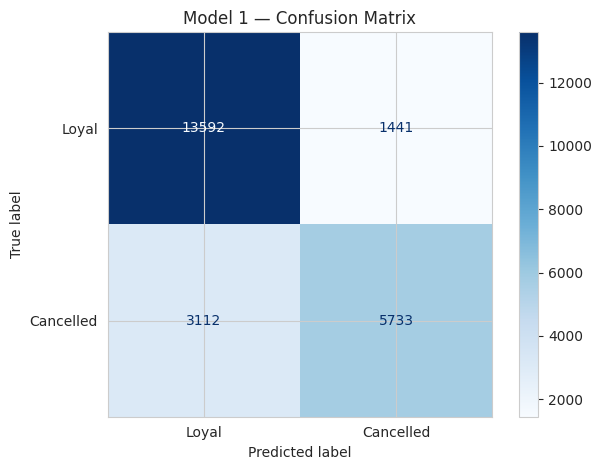

              precision    recall  f1-score   support

       Loyal       0.81      0.90      0.86     15033
   Cancelled       0.80      0.65      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.81      0.80     23878



In [15]:
# Confusion Matrix
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Loyal', 'Cancelled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Loyal', 'Cancelled']))

Let's examine the following:
- Positive Predictive Value (PPV) = if our model predicts a cancellation, how often is it correct?
- Negative Predictive Value (NPV) = if our model predicts a loyal customer, how often is it correct?
- Sensitivity = fraction of all cancellations correctly predicted (probably most important here)
- Specificity = fraction of all loyal customers correctly predicted

In [16]:
TN = cm_m1[0, 0]
FP = cm_m1[0, 1]
FN = cm_m1[1, 0]
TP = cm_m1[1, 1]

# Positive Predictive Value (PPV) 
PPV = TP / (TP + FP)

# Negative Predictive Value (NPV)
NPV = TN / (TN + FN)

# Sensitivity 
Sensitivity = TP / (TP + FN)

# Specificity 
Specificity = TN / (TN + FP)

print(f"PPV: {PPV:.3f}")
print(f"NPV: {NPV:.3f}")
print(f"Sensitivity: {Sensitivity:.3f}")
print(f"Specificity: {Specificity:.3f}")

PPV: 0.799
NPV: 0.814
Sensitivity: 0.648
Specificity: 0.904


Looks like our model is correct 80% of the time when predicting a cancellation and 81% of the time when predicting a loyal customer. It's also good at identifying loyal customers (specificity), but could use some work correctly identifying a cancellation (sensitivity is only 0.648).

ROC Curve and AUC:

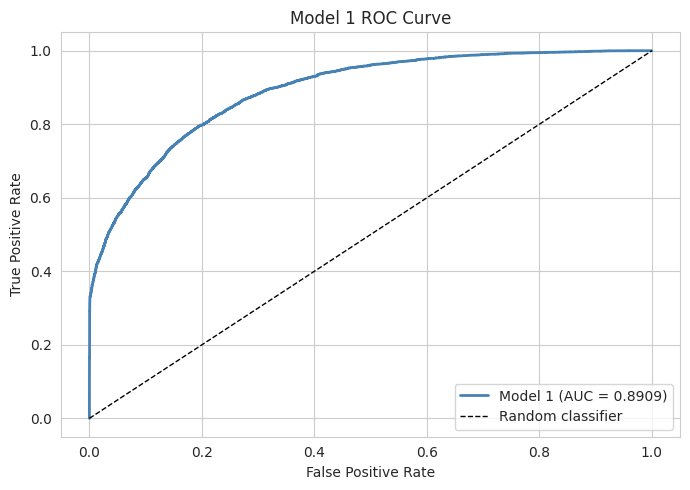

Model 1 ROC-AUC: 0.8909


In [17]:
y_prob_m1 = pipe_m1.predict_proba(X_test)[:, 1]  # probability of class 1

fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_prob_m1)
auc_m1 = roc_auc_score(y_test, y_prob_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")


---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



Let's first create a function we can use to evaluate the model:

In [7]:
def evaluate_model(pipe, X_test, y_test):
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]  # probability for positive class

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tp = cm[1, 1]
    print("Confusion Matrix:")
    print(np.array([[tn, fp],[fn, tp]]))

    # Metrics
    PPV = tp / (tp + fp)
    NPV = tn / (tn + fn)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    auc = roc_auc_score(y_test, y_proba)

    print(f" \nReport: \n {classification_report(y_test, y_pred, target_names=['Loyal', 'Cancelled'])}")
    print(f"\nPPV: {PPV:.3f}, NPV: {NPV:.3f}, Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}, AUC: {auc:.4f}")

Now we try two other solvers: liblinear and saga

In [19]:
solvers = ['liblinear', 'saga']
model_2_results = {}

for solver in solvers:
    print(f"\n=== Evaluating solver: {solver} ===")
    
    model_2_pipe = Pipeline(steps=[
        ('prep', preprocessor_m1),  # same preprocessing
        ('model', LogisticRegression(solver=solver, max_iter=5000, random_state=83))
    ])
    
    model_2_pipe.fit(X_train, y_train)
    evaluate_model(model_2_pipe, X_test, y_test)
    
    model_2_results[solver] = model_2_pipe


=== Evaluating solver: liblinear ===
Confusion Matrix:
[[13590  1443]
 [ 3100  5745]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.81      0.90      0.86     15033
   Cancelled       0.80      0.65      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.81      0.80     23878


PPV: 0.799, NPV: 0.814, Sensitivity: 0.650, Specificity: 0.904, AUC: 0.8910

=== Evaluating solver: saga ===
Confusion Matrix:
[[13587  1446]
 [ 3099  5746]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.81      0.90      0.86     15033
   Cancelled       0.80      0.65      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.81      0.80     23878


PPV: 0.799, NPV: 0.814, Sensitivity: 0.650, Specificity: 0.904, AUC: 0.8910

All 3 models look basically identical. Changing the solver negligibly improved the model: the sensitivity for both the liblinear and saga solvers was 0.650 (up from 0.648 from the first model) and the AUC for both was 0.8910 (up from 0.8909 from the first model). Switching solvers did not meaningfully improve model performance, which is likely due to the dataset being so large.

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much?
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class?

In [16]:
# Creating the Pipeline, using class_weight = "balanced"

pipe_m3 = Pipeline(steps=[
    ('prep', preprocessor_m1),
    ('model', LogisticRegression(max_iter=5000, random_state=83, class_weight='balanced'))   # using the default solver lbfgs
])

# Creating the cross-validation object
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=83)

In [21]:
# Run the cross-validation, evaluated using ROC-AUC

cv_auc = cross_val_score(pipe_m3, X, y, cv=cv, scoring='roc_auc')

print(f"  ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}")

  ROC-AUC : 0.8938  ± 0.0011  | folds: [0.892  0.8941 0.8945 0.895  0.8932]


In [18]:
# Now we fit the model on the test set and evaluate using the function

pipe_m3.fit(X_train, y_train)

evaluate_model(pipe_m3, X_test, y_test)

Confusion Matrix:
[[12318  2715]
 [ 1962  6883]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.86      0.82      0.84     15033
   Cancelled       0.72      0.78      0.75      8845

    accuracy                           0.80     23878
   macro avg       0.79      0.80      0.79     23878
weighted avg       0.81      0.80      0.81     23878


PPV: 0.717, NPV: 0.863, Sensitivity: 0.778, Specificity: 0.819, AUC: 0.8913


An increase in recall/sensitivity! 

Despite seeing an increase in false positives (predicting a cancel on a loyal customer), there is a decrease in false negatives (predicted a loyal customer but they actually cancel), which is significant because false negatives are much more costly. 

Now let's change the cross validation folds from 5 to 10 to see if there's a difference in AUC:

In [23]:
cv_2 = StratifiedKFold(n_splits=10, shuffle=True, random_state=83)
cv_auc2 = cross_val_score(pipe_m3, X, y, cv=cv_2, scoring='roc_auc')

print(f"  ROC-AUC : {cv_auc2.mean():.4f}  ± {cv_auc2.std():.4f}  | folds: {np.round(cv_auc2, 4)}")

  ROC-AUC : 0.8938  ± 0.0020  | folds: [0.8942 0.8906 0.8961 0.8924 0.8928 0.8961 0.8973 0.8928 0.8929 0.8931]


The AUC doesn't change at all really; the mean remained the same and the standard deviation increased ever so slightly.

Now let's remove class_weights = 'balanced' and see how it affects recall:

In [24]:
pipe_m3_unbalanced = Pipeline(steps=[
    ('prep', preprocessor_m1),
    ('model', LogisticRegression(
        max_iter=5000,
        random_state=83
    ))
])

pipe_m3_unbalanced.fit(X_train, y_train)
evaluate_model(pipe_m3_unbalanced, X_test, y_test)

Confusion Matrix:
[[13592  1441]
 [ 3112  5733]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.81      0.90      0.86     15033
   Cancelled       0.80      0.65      0.72      8845

    accuracy                           0.81     23878
   macro avg       0.81      0.78      0.79     23878
weighted avg       0.81      0.81      0.80     23878


PPV: 0.799, NPV: 0.814, Sensitivity: 0.648, Specificity: 0.904, AUC: 0.8909


This model is just the same as model 1 --> there's a clear dip in recall (sensitivity), making our model more costly in its false negatives.

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

**Conclusion**

After our model-building, it can be concluded that model 3 should be used to predict hotel cancellations for our business. While the overall accuracy is ever-so-slightly lower than models 1 and 2, it achieved a higher recall (sensitivity), meaning that it does a better job at correctly identifying a larger proportion of cancellations. Recall is the most important metric to evaluate here because we want to minimize the number of actual cancellations that were predicted as loyal customers (false negatives); those scenarios are the most costly because we would have empty rooms and thus losing possibe revenue gain from those rooms. False positives, or predicting cancellations on actual loyal customers, are less costly because that means we would over-staff or over-book slightly. Model 3 had the lowest proportion of false negatives, making it the model we should deploy. 

The reason model 3 works the best is because it uses class_weights = "balanced." This means that the model pays more attention to the minority class of cancellations (since only around 37% of the data are customers who cancelled). Here, we are changing the type of error the model prioritizes; we're essentially telling the model that missing cancellations (false negatives) are more costly than missing false alarms (false positives), so the model needs to focus on catching them. Additionally, we used cross validation in model 3 with 5 folds. Although this doesn't directly improve model performance, it gives a more reliable estimate of the results because each fold of the data rotates as the testing set. Overall, the hotel should implement model 3 because it's the best at identifying cancellations.

**Tuning C**

The parameter C controls the regularization strength of the model. Smaller values of C correspond to stronger regularization that create simpler models, which might lead to underfitting. Larger values of C correspond to weaker regularization, allowing models to fit the training data more clasely, which might lead to overfitting. We can tune C over a range to find the best value for our model (we'll continue to use model 3 here).

Here's what GridSearch CV does to accomplish this goal:
- Tries multiple values of a parameter, like C in this case
- Uses cross-validation to evaluate each value
- Picks the parameter value with the best performance according to a given metric (roc-auc)

In [27]:
# Define parameter grid that's used in GridSearchCV
param_grid = {'model__C': [0.001, 0.01, 0.1, 1, 10, 100]}  #param_grid requires a dictionary 

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe_m3,       # using the model 3 pipeline (balanced class weights)
    param_grid=param_grid,
    cv=5,                    # cross-validation folds
    scoring='roc_auc',        # metric to optimize
    n_jobs=-1                 # using all CPU cores
)

# Fit to training data
grid_search.fit(X_train, y_train)

# Best value
print("Best C:", grid_search.best_params_)

# Best CV score
print("Best ROC-AUC:", grid_search.best_score_)

Best C: {'model__C': 100}
Best ROC-AUC: 0.897499041930865


In [28]:
# Use the best estimator from GridSearchCV
best_model = grid_search.best_estimator_

# Evaluate it on the test set
evaluate_model(best_model, X_test, y_test)

Confusion Matrix:
[[12357  2676]
 [ 1908  6937]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.87      0.82      0.84     15033
   Cancelled       0.72      0.78      0.75      8845

    accuracy                           0.81     23878
   macro avg       0.79      0.80      0.80     23878
weighted avg       0.81      0.81      0.81     23878


PPV: 0.722, NPV: 0.866, Sensitivity: 0.784, Specificity: 0.822, AUC: 0.8960


This is actually the best model we've seen so far in terms of identifying cancellations, with an AUC of 0.896 and a Sensitvity of 0.784. 

Let's also check the results for the other values of C:

In [29]:
# Convert cv_results_ to a DataFrame
results = pd.DataFrame(grid_search.cv_results_)
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.609344,0.144941,0.125054,0.010866,0.001,{'model__C': 0.001},0.851634,0.848024,0.853333,0.853505,0.857676,0.852835,0.003121,6
1,2.371530,0.126930,0.137413,0.027187,0.010,{'model__C': 0.01},0.871899,0.870394,0.873835,0.872549,0.881642,0.874064,0.003948,5
2,3.301689,0.210748,0.145093,0.057632,0.100,{'model__C': 0.1},0.883440,0.883555,0.885444,0.884266,0.892009,0.885743,0.003213,4
3,7.637142,1.031477,0.117428,0.006571,1.000,{'model__C': 1},0.891366,0.891373,0.892729,0.893617,0.896803,0.893177,0.002004,3
4,13.437122,2.084763,0.116517,0.004630,10.000,{'model__C': 10},0.895440,0.895433,0.896843,0.898086,0.900218,0.897204,0.001802,2
5,11.279273,0.719404,0.118930,0.039777,100.000,{'model__C': 100},0.895588,0.895506,0.896879,0.898397,0.901125,0.897499,0.002096,1


We can see an increase in AUC as the C value increases (although the difference between C = 10 and C = 100 is quite low)

**Engineer New Features**

Let's add some new columns to the initial dataframe:

In [8]:
# Total nights stayed
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [9]:
# Season
month_to_season = {
    'January': 'Winter', 'February': 'Winter', 'December': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
}

df['season'] = df['arrival_date_month'].map(month_to_season)


In [10]:
# Family: binary column -- 1 if have at least one child or baby, else 0
df['family'] = ((df['children'] + df['babies']) > 0).astype(int)

Now that we have 3 new features, let's add them to our categorical and numerical feature lists from step 3:

In [11]:
CATEGORICAL = CATEGORICAL + ['season', 'family']
NUMERIC = NUMERIC + ['total_nights']

In [ ]:
# Reassigning X to include new features
X = df[CATEGORICAL + NUMERIC]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=83, stratify=y
)

In [16]:
# New Precprocessor to include new features:
preprocessor_new = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC)
])

# Pipeline

pipe_new = Pipeline(steps=[
    ('prep', preprocessor_new),
    ('model', LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced', random_state=83))
])

# Fit and evaluate
pipe_new.fit(X_train, y_train)

evaluate_model(pipe_new, X_test, y_test)

Confusion Matrix:
[[12327  2706]
 [ 1978  6867]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.86      0.82      0.84     15033
   Cancelled       0.72      0.78      0.75      8845

    accuracy                           0.80     23878
   macro avg       0.79      0.80      0.79     23878
weighted avg       0.81      0.80      0.81     23878


PPV: 0.717, NPV: 0.862, Sensitivity: 0.776, Specificity: 0.820, AUC: 0.8911


Not really a big change in model performance - this looks pretty similar to model 3. 

Let's also use cross validation:

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=83)

cv_scores = cross_val_score(pipe_new, X, y, cv=cv, scoring='roc_auc')

print(f"ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

ROC-AUC: 0.8937 ± 0.0010


Again, no real change in performance. 

**Different Model - RandomForestClassifier**

Random Forest builds many decision trees where each tree sees a random subset of the data. For each subset, only a random grouping of features is used to reduce correlation between trees. Final predictions are then made through a majority vote from all trees.

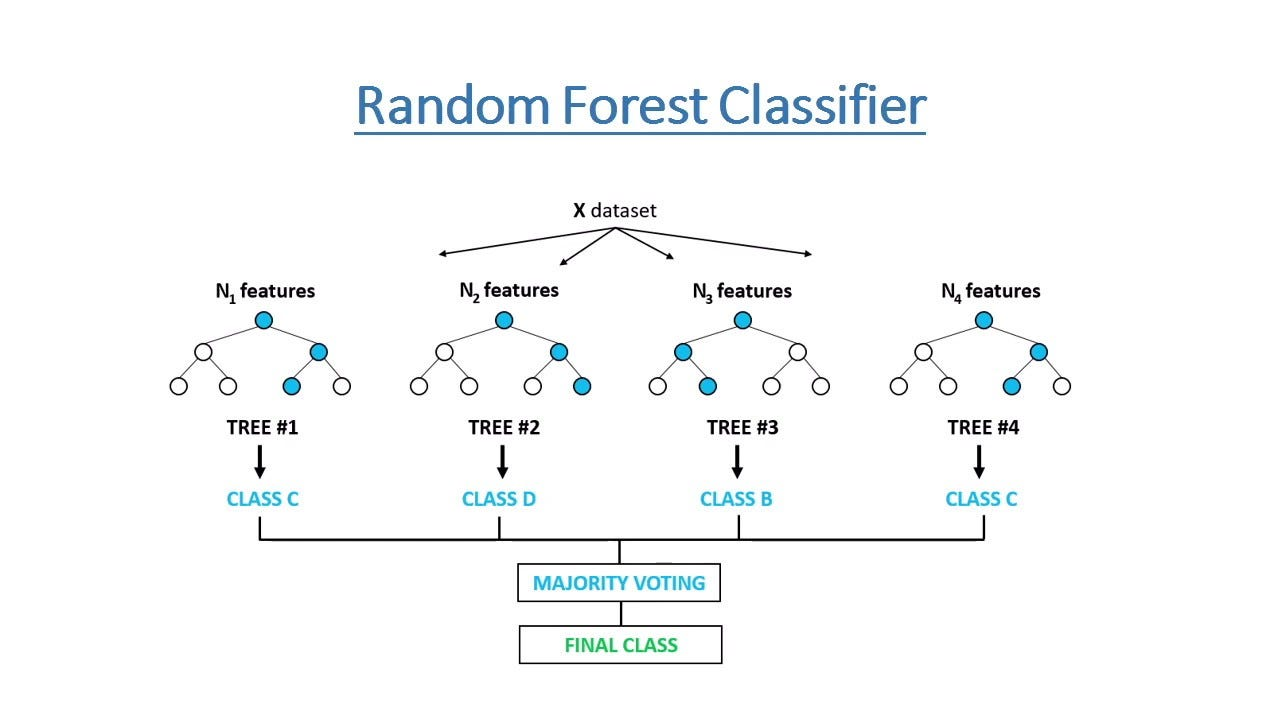

In [20]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ('prep', preprocessor_m1),   # same preprocessing
    ('model', RandomForestClassifier(
        n_estimators=100,     # n_estimators defines how many trees in the forest
        random_state=83,
        n_jobs=-1
    ))
])

pipe_rf.fit(X_train, y_train)

evaluate_model(pipe_rf, X_test, y_test)

Confusion Matrix:
[[14167   866]
 [ 1828  7017]]
 
Report: 
               precision    recall  f1-score   support

       Loyal       0.89      0.94      0.91     15033
   Cancelled       0.89      0.79      0.84      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878


PPV: 0.890, NPV: 0.886, Sensitivity: 0.793, Specificity: 0.942, AUC: 0.9527


This is the best model we've seen! Not only is the sensitivity the highest at 0.793, but it's overall predictive power does not dip like it did in model 3 when we used balanced classes (in fact it's accuracy is also the highest we've seen). Also, we see a significant improvement in AUC with a value of 0.9527.

Why is this the case?

Logistic regression is a linear model because it uses a linear combination of feature variables (columns), and then uses a sigmoid function to map linear outputs to probabilities. This hotel dataset likely has patterns that a linear model can't easily capture, which is why a flexible nonlinear model like Random Forest might perform better. 

**Interpret Coefficients**

Let's do a horiztonal bar chart of the features and their coefficients for model 3

In [ ]:
# Extracting coefficients from the pipeline
model = pipe_m3.named_steps['model']
coefs = model.coef_[0]

# Extracting the features --> Note: there's a lot of them since the categorical variabes were encoded
feature_names = pipe_m3.named_steps['prep'].get_feature_names_out()

In [ ]:
# Dataframe of coefficients
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

# Sort by importance by absolute value
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

coef_df.head(10)

,feature,coefficient,abs_coef
246,num__required_car_parking_spaces,-24.564010,24.564010
241,num__previous_cancellations,16.668703,16.668703
245,num__adr,6.741374,6.741374
243,num__booking_changes,-6.295775,6.295775
242,num__previous_bookings_not_canceled,-6.075033,6.075033


- Required parking spaces has the most powerful influence on predicting a cancellation, where customers who request parking are much less likely to cancel (means that their plans are more likely to be set in stone).
- The number of previous cancellations has the strongest positive coefficient; the higher the number of previous cancellations, the more likely a customer is predicted to cancel again.
- ADR, or average daily rate, also has a high positive coefficient --> higher room prices = higher chance of cancellation
- The number of booking changes and previous bookings not cancelled also have higher negative coefficients: customers who made more booking changes are less likely to cancel, and same goes for customers who've went through on their bookings with the hotel in the past.

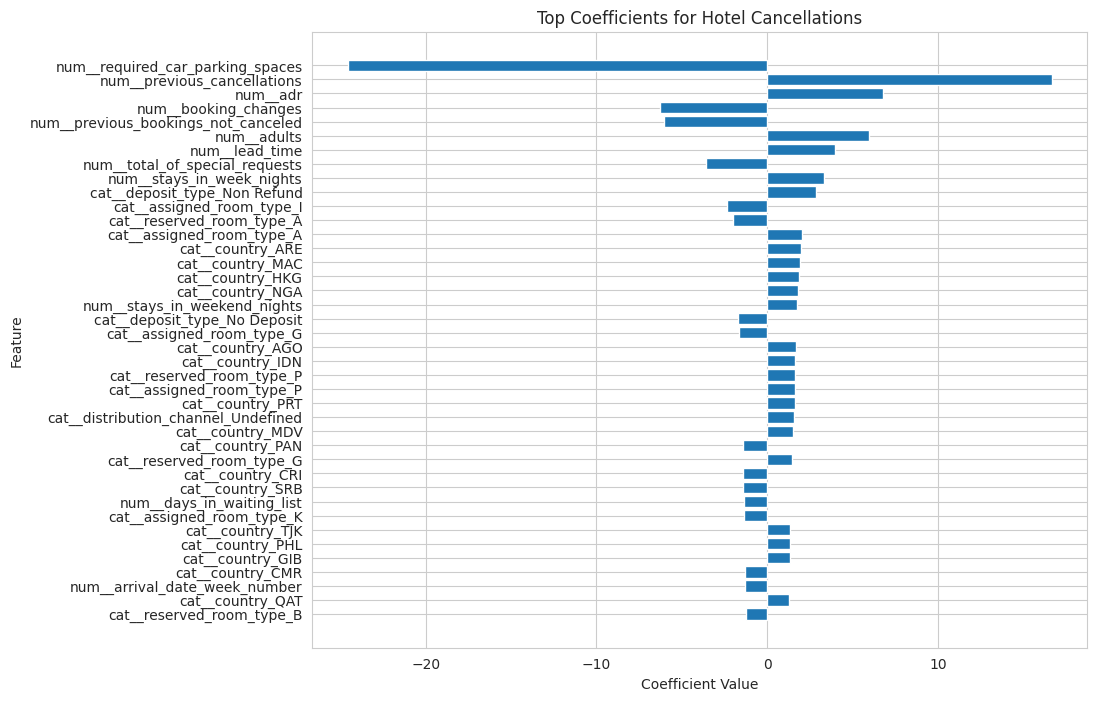

In [28]:
# Now we plot
plt.figure(figsize=(10, 8))

top_n = 40  # show top 40 features
subset = coef_df.head(top_n)

plt.barh(subset['feature'], subset['coefficient'])
plt.gca().invert_yaxis()  # goes top to bottom for the ranking

plt.title("Top Coefficients for Hotel Cancellations")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.show()

Overall, features with larger positive cancellations increase cancellation risk flagged by the model, while larger negative coefficients indicate more loyal bookings.

It looks like the top several features have a significant impact on predicting cancellations and then the coefficient values diminish from there, which makes sense considering that there are 248 separate features (includes the one-hot encoded variables).

Also, it's interesting to note that the numerical features are mostly at the top of the ranking, meaning that they are more influential on the model in how it predicts a cancellation. The top categorical feature is a Non Refund deposit type, which interestingly has a positive coefficient, meaning that bookings with non-refundable deposits are associated with customers who are more likely to cancel. This sounds counterintuitive, but the model is just picking up patterns in the dataset (not necessarily looking at cause and effect). One way to explain this is that hotels offer cheaper bookings with non-refunds attached, so customers might not feel all that bad if they cancel and lose only a little bit of money.